# 04 - Evaluation

The held-out test seasons are scored here, **once**, after everything is frozen.
Nothing in this notebook may feed back into a modelling decision -- that is the
entire point of having held them back.

Per target family: baseline comparison, significance, calibration, and a per-league
breakdown that doubles as the pooling sanity check.

In [1]:
# The package is installed editable (`pip install -e .`), so this works from any
# working directory -- no `os.getcwd()` gymnastics.
import fpp
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
print("fpp", fpp.__version__, "| targets:", fpp.TARGETS)

fpp 0.1.0 | targets: ('goals', 'shots', 'sot', 'corners')


In [2]:
from fpp.config import FULL

df = fpp.clean.load_clean_table()
ctx = fpp.RunContext.load()
print("scoring artifact version:", ctx.version)
print("test boundary:", fpp.TEST_SEASON, "(seasons >= this are held out)")

scoring artifact version: v2026-08-25
test boundary: 2025/2026 (seasons >= this are held out)


## 1. Score the test seasons

Reported on **both** metrics, for all four targets, always labelled:

* **per-team** -- each side scored against its own actual. This is what training
  and feature selection optimise (`cv.evaluate`).
* **match-total** -- the two sides convolved into one total, then scored. This is
  what the priced product actually delivers.

They answer different questions and are not comparable to each other: different
bucket grids (`team_cap` vs `total_cap`) and a different number of scoring rows.
Compare a model to a baseline *within* a metric, never one metric to the other.

In [3]:
test_results, paired_model, paired_base, dispersions = {}, {}, {}, {}

for t in fpp.TARGETS:
    w, feats = ctx.windows[t], ctx.features[t]
    bw = fpp.BufferWindows(df, L_max=max(50, int(w["L"])))
    ft = fpp.build_feature_table(df, bw, int(w["L"]), float(w["alpha"]), features=feats)

    params = dict(ctx.params[t]); params["n_estimators"] = ctx.n_estimators[t]
    m, disp = fpp.evaluate.fit_predict_test(ft, t, params, feats, fit_cfg=FULL)
    b = fpp.evaluate.baseline_test(ft, t)

    paired_model[t], paired_base[t], dispersions[t] = m, b, disp
    # Both metrics, both models: four rows per target, each naming its own metric.
    # They answer different questions, so neither replaces the other.
    test_results[t] = [
        fpp.evaluate.headline_team(b, t, disp, "Baseline"),
        fpp.evaluate.headline_team(m, t, disp, "Model"),
        fpp.evaluate.headline_total(b, t, disp, "Baseline"),
        fpp.evaluate.headline_total(m, t, disp, "Model"),
    ]
    print(f"  {t:8} scored {len(m):,} test fixtures")

summary = pd.DataFrame([r for rows in test_results.values() for r in rows])

print()
print("per-team    = each side against its own actual  (the training/selection objective)")
print("match-total = the convolved match total         (what the priced product delivers)")
print("Different bucket grids and different row counts: compare across models,")
print("never across metrics.")
print()
for t in fpp.TARGETS:
    ll = {(r["metric"], r["model"]): r["logloss"] for r in test_results[t]}
    print(f"  {t:8} per-team ll={ll['team', 'Model']:.4f} (baseline {ll['team', 'Baseline']:.4f})"
          f"  |  match-total ll={ll['total', 'Model']:.4f} (baseline {ll['total', 'Baseline']:.4f})")

display(summary.pivot(index="target", columns=["metric", "model"], values="logloss").round(4))

  goals    scored 1,797 test fixtures
  shots    scored 1,729 test fixtures
  sot      scored 1,729 test fixtures
  corners  scored 1,729 test fixtures

per-team    = each side against its own actual  (the training/selection objective)
match-total = the convolved match total         (what the priced product delivers)
Different bucket grids and different row counts: compare across models,
never across metrics.

  goals    per-team ll=1.4464 (baseline 1.5045)  |  match-total ll=1.8674 (baseline 1.8782)
  shots    per-team ll=2.8481 (baseline 3.0070)  |  match-total ll=3.1362 (baseline 3.1617)
  sot      per-team ll=2.1467 (baseline 2.2529)  |  match-total ll=2.4871 (baseline 2.5107)
  corners  per-team ll=2.3262 (baseline 2.3908)  |  match-total ll=2.6398 (baseline 2.6469)


metric      team            total        
model   Baseline   Model Baseline   Model
target                                   
corners   2.3908  2.3262   2.6469  2.6398
goals     1.5045  1.4464   1.8782  1.8674
shots     3.0070  2.8481   3.1617  3.1362
sot       2.2529  2.1467   2.5107  2.4871

## 2. Is the edge real?

Paired bootstrap CI and a Wilcoxon signed-rank test on the log-loss difference,
run separately for each metric. An edge whose CI straddles zero is not an edge,
and should be reported as such.

Watch for the two metrics disagreeing: an edge in predicting each side need not
survive convolution into the match total, and that is a real finding rather than
a contradiction.

In [4]:
sig = pd.DataFrame(
    [fpp.evaluate.significance_team(paired_model[t], paired_base[t], t, dispersions[t])
     for t in fpp.TARGETS]
    + [fpp.evaluate.significance_total(paired_model[t], paired_base[t], t, dispersions[t])
       for t in fpp.TARGETS]
)
cols = ["target", "metric", "n", "mean_gain", "median_gain", "win_rate",
        "ci_lo", "ci_hi", "wilcoxon_p",
        "ci_excludes_zero", "wilcoxon_significant", "significant"]
display(sig[cols].round(5))

# The two tests answer different questions -- the bootstrap CI is about the mean
# of the paired differences, Wilcoxon about the median. Log-loss differences are
# right-skewed, so they can legitimately disagree, and `significant` requires both.
#
# Each line names its metric, so a per-team verdict is never read as a match-total
# one. The two can legitimately disagree as well: an edge in predicting each side
# need not survive convolution into the total, and that is worth knowing.
for r in sig.to_dict("records"):
    print(" ", fpp.evaluate.describe_significance(r))

if sig["tests_disagree"].any():
    print("\nWhere the tests disagree, the edge is not a consistent shift across")
    print("fixtures -- it is concentrated in a minority of them. Read the win rate.")

for t in fpp.TARGETS:
    v = sig[sig["target"] == t].set_index("metric")["significant"]
    if v["team"] != v["total"]:
        print(f"\n  {t}: significant per-team={v['team']}, match-total={v['total']} -- the edge "
              f"does not survive the switch between the two questions.")

,target,metric,n,mean_gain,median_gain,win_rate,ci_lo,ci_hi,wilcoxon_p,ci_excludes_zero,wilcoxon_significant,significant
0,goals,team,3594,0.05817,0.03432,0.60072,0.04668,0.06976,0.00000,True,True,True
1,shots,team,3458,0.15891,0.04654,0.59398,0.13932,0.17888,0.00000,True,True,True
2,sot,team,3458,0.10613,0.02407,0.57027,0.09048,0.12211,0.00000,True,True,True
3,corners,team,3458,0.06464,0.02539,0.56651,0.05322,0.07612,0.00000,True,True,True
4,goals,total,1797,0.01078,0.00050,0.50696,0.00141,0.02015,0.49229,True,False,False
5,shots,total,1729,0.02548,0.00386,0.51880,0.01423,0.03713,0.00277,True,True,True
6,sot,total,1729,0.02364,0.00382,0.53036,0.01249,0.03501,0.00274,True,True,True
7,corners,total,1729,0.00710,-0.00272,0.47773,-0.00170,0.01580,0.37028,False,False,False


  goals [team]: edge of +0.05817 confirmed by both tests (CI [+0.04668, +0.06976], Wilcoxon p=1.95e-20)
  shots [team]: edge of +0.15891 confirmed by both tests (CI [+0.13932, +0.17888], Wilcoxon p=6.49e-48)
  sot [team]: edge of +0.10613 confirmed by both tests (CI [+0.09048, +0.12211], Wilcoxon p=3.3e-31)
  corners [team]: edge of +0.06464 confirmed by both tests (CI [+0.05322, +0.07612], Wilcoxon p=3.13e-26)
  goals [total]: mean gain +0.01078 excludes zero, but the median gain is +0.00050 and the model wins only 50.7% of fixtures (Wilcoxon p=0.492). The edge sits in a minority of fixtures rather than being a consistent shift -- not counted as significant.
  shots [total]: edge of +0.02548 confirmed by both tests (CI [+0.01423, +0.03713], Wilcoxon p=0.00277)
  sot [total]: edge of +0.02364 confirmed by both tests (CI [+0.01249, +0.03501], Wilcoxon p=0.00274)
  corners [total]: no edge distinguishable from zero (CI [-0.00170, +0.01580], Wilcoxon p=0.37)

Where the tests disagree, the

## 3. Per-league breakdown - the pooling sanity check

One model serves all five leagues. If a league is quietly underperforming here
relative to what a dedicated model would manage, this is where it shows up. Treat a
bad segment as a signal to investigate, not a line in a report.

In [5]:
for t in fpp.TARGETS:
    print(f"\n=== {t} ===")
    for label, seg in (("per-team", fpp.evaluate.by_league_team(
                            paired_model[t], paired_base[t], t, dispersions[t])),
                       ("match-total", fpp.evaluate.by_league_total(
                            paired_model[t], paired_base[t], t, dispersions[t]))):
        print(f"  -- {label} --")
        display(seg.round(4))
        if seg["edge"].notna().any():
            worst = seg.loc[seg["edge"].idxmin()]
            if worst["edge"] < 0:
                print(f"  ! {worst['league']} is behind the baseline by "
                      f"{-worst['edge']:.4f} on {label} - investigate")


=== goals ===
  -- per-team --


,league,metric,n,model_logloss,baseline_logloss,edge,model_mae
0,Bund,team,306,1.5288,1.6110,0.0822,0.9873
1,Liga,team,396,1.3845,1.4508,0.0663,0.8143
2,Ligue,team,315,1.5244,1.5699,0.0455,1.0313
3,Prem,team,390,1.4464,1.4806,0.0342,0.9015
4,Serie,team,390,1.3814,1.4467,0.0653,0.8706


  -- match-total --


,league,metric,n,model_logloss,baseline_logloss,edge,model_mae
0,Bund,total,306,1.9330,1.9587,0.0257,1.3562
1,Liga,total,396,1.7863,1.8012,0.0150,1.1901
2,Ligue,total,315,1.9964,2.0004,0.0040,1.5081
3,Prem,total,390,1.8513,1.8458,-0.0054,1.2386
4,Serie,total,390,1.8102,1.8267,0.0165,1.2719


  ! Prem is behind the baseline by 0.0054 on match-total - investigate

=== shots ===
  -- per-team --


...


=== corners ===
  -- per-team --


,league,metric,n,model_logloss,baseline_logloss,edge,model_mae
0,Bund,team,306,2.3420,2.3936,0.0517,2.1034
1,Liga,team,375,2.3408,2.3982,0.0574,2.1377
2,Ligue,team,305,2.3506,2.4019,0.0513,2.1645
3,Prem,team,370,2.3353,2.3843,0.0490,2.0693
4,Serie,team,373,2.2695,2.3784,0.1089,2.0378


  -- match-total --


,league,metric,n,model_logloss,baseline_logloss,edge,model_mae
0,Bund,total,306,2.7011,2.6905,-0.0106,2.8852
1,Liga,total,375,2.6495,2.6465,-0.0030,2.7088
2,Ligue,total,305,2.6746,2.6670,-0.0077,2.7974
3,Prem,total,370,2.6242,2.6211,-0.0031,2.6528
4,Serie,total,373,2.5666,2.6205,0.0539,2.5277


  ! Bund is behind the baseline by 0.0106 on match-total - investigate


## 4. Calibration

Log loss says whether this model beats that one. It does not say whether "62%"
means 62%, and that is what decides whether a priced ladder is usable.

The question this section answers, per target: **which of these markets can I
actually trust, and where does each one go wrong?**

Three grades. `TRUST` is well calibrated across the range. `CAUTION` is usable
with a known bias. `AVOID` is either badly wrong on average (ECE) or has
probabilities that are far too extreme (calibration slope) -- and the slope rule
matters on its own, because when predictions cluster near the base rate the
average error stays small while the *confident* calls, the only ones worth
acting on, are badly wrong.

In [6]:
cal_summary, cal_bins = fpp.calibration.calibration_report(paired_model, dispersions)
verdicts = fpp.calibration.line_verdicts(cal_summary, cal_bins)

print("Which markets can be trusted\n")
display(fpp.calibration.summarise_by_target(verdicts).round(3))


Which markets can be trusted



,target,metric,lines,trust,caution,avoid,mean_ece,mean_slope,trusted_markets,avoid_markets
0,corners,team,4,4,0,0,0.017,1.047,"Over 3.5, Over 4.5, Over 5.5, Over 6.5",-
1,corners,total,4,0,4,0,0.035,0.679,-,-
2,goals,team,4,2,2,0,0.020,1.046,"Over 0.5, Over 1.5",-
3,goals,total,4,2,2,0,0.025,0.972,"Over 0.5, Over 1.5",-
4,shots,team,4,3,1,0,0.023,1.042,"Over 8.5, Over 10.5, Over 14.5",-
5,shots,total,4,1,1,2,0.047,1.013,Over 26.5,"Over 20.5, Over 22.5"
6,sot,team,4,1,3,0,0.027,0.998,Over 5.5,-
7,sot,total,4,1,3,0,0.030,0.832,Over 6.5,-


### 4a. Every market, and what is wrong with it

One row per over/under line, with the failure named in plain terms. This is the
table to act on; everything below it is the working.

In [7]:
cols = ["metric", "market", "n", "predicted", "actual", "ece", "slope", "bands_off", "verdict", "reading"]
for t in fpp.TARGETS:
    print(f"===== {t.upper()} =====")
    display(verdicts[verdicts["target"] == t][cols].round(3).style.hide(axis="index"))


===== GOALS =====


metric,market,n,predicted,actual,ece,slope,bands_off,verdict,reading
team,Over 0.5,3594,0.742000,0.735000,0.020000,1.137000,1,TRUST,under-predicts in 1 of 10 bands (around 90%); worst says 90% where it happens 94%
team,Over 1.5,3594,0.411000,0.399000,0.022000,0.940000,0,TRUST,reliable across the whole probability range
team,Over 2.5,3594,0.183000,0.171000,0.018000,1.035000,2,CAUTION,over-predicts in 2 of 10 bands (12%-24%); worst says 24% where it happens 19%
team,Over 3.5,3594,0.069000,0.053000,0.022000,1.074000,3,CAUTION,"too confident at both ends - under-predicts around 6%, over-predicts 3%-12%; worst says 12% where it happens 7%"
total,Over 0.5,1797,0.940000,0.934000,0.016000,1.178000,1,TRUST,over-predicts in 1 of 10 bands (around 95%); worst says 95% where it happens 91%
total,Over 1.5,1797,0.775000,0.765000,0.020000,0.840000,0,TRUST,reliable across the whole probability range
total,Over 2.5,1797,0.544000,0.529000,0.031000,0.882000,1,CAUTION,over-predicts in 1 of 10 bands (around 55%); worst says 55% where it happens 47%
total,Over 3.5,1797,0.326000,0.296000,0.033000,0.987000,1,CAUTION,over-predicts in 1 of 10 bands (around 31%); worst says 31% where it happens 24%


===== SHOTS =====


metric,market,n,predicted,actual,ece,slope,bands_off,verdict,reading
team,Over 8.5,3458,0.757000,0.769000,0.020000,0.993000,1,TRUST,under-predicts in 1 of 10 bands (around 95%); worst says 95% where it happens 99%
team,Over 10.5,3458,0.599000,0.615000,0.022000,1.062000,1,TRUST,under-predicts in 1 of 10 bands (around 89%); worst says 89% where it happens 94%
team,Over 12.5,3458,0.440000,0.463000,0.030000,1.071000,2,CAUTION,under-predicts in 2 of 10 bands (40%-79%); worst says 40% where it happens 47%
team,Over 14.5,3458,0.302000,0.318000,0.022000,1.041000,1,TRUST,under-predicts in 1 of 10 bands (around 67%); worst says 67% where it happens 73%
total,Over 20.5,1729,0.724000,0.783000,0.059000,0.876000,6,AVOID,under-predicts in 6 of 10 bands (58%-85%); worst says 67% where it happens 77%
total,Over 22.5,1729,0.607000,0.677000,0.070000,1.080000,7,AVOID,under-predicts in 7 of 10 bands (45%-77%); worst says 77% where it happens 88%
total,Over 24.5,1729,0.485000,0.518000,0.039000,1.049000,2,CAUTION,under-predicts in 2 of 10 bands (38%-66%); worst says 38% where it happens 47%
total,Over 26.5,1729,0.369000,0.378000,0.017000,1.047000,0,TRUST,reliable across the whole probability range


===== SOT =====


metric,market,n,predicted,actual,ece,slope,bands_off,verdict,reading
team,Over 2.5,3458,0.764000,0.756000,0.029000,1.021000,3,CAUTION,over-predicts in 3 of 10 bands (73%-79%); worst says 79% where it happens 74%
team,Over 3.5,3458,0.593000,0.590000,0.033000,1.016000,3,CAUTION,over-predicts in 1 of 10 bands (around 57%); under-predicts in 2 of 10 bands (47%-86%); worst says 57% where it happens 49%
team,Over 4.5,3458,0.421000,0.413000,0.027000,0.948000,2,CAUTION,over-predicts in 2 of 10 bands (38%-61%); worst says 61% where it happens 54%
team,Over 5.5,3458,0.277000,0.283000,0.018000,1.008000,0,TRUST,reliable across the whole probability range
total,Over 6.5,1729,0.739000,0.741000,0.023000,0.867000,0,TRUST,reliable across the whole probability range
total,Over 7.5,1729,0.617000,0.629000,0.035000,0.851000,0,CAUTION,reliable across the whole probability range
total,Over 8.5,1729,0.488000,0.500000,0.035000,0.741000,2,CAUTION,under-predicts in 2 of 10 bands (33%-42%); worst says 42% where it happens 51%; overconfident overall (slope 0.74)
total,Over 9.5,1729,0.367000,0.364000,0.027000,0.868000,1,CAUTION,over-predicts in 1 of 10 bands (around 43%); worst says 43% where it happens 34%


===== CORNERS =====


metric,market,n,predicted,actual,ece,slope,bands_off,verdict,reading
team,Over 3.5,3458,0.625000,0.634000,0.018000,1.075000,0,TRUST,reliable across the whole probability range
team,Over 4.5,3458,0.475000,0.485000,0.018000,1.038000,0,TRUST,reliable across the whole probability range
team,Over 5.5,3458,0.341000,0.352000,0.016000,1.038000,0,TRUST,reliable across the whole probability range
team,Over 6.5,3458,0.235000,0.245000,0.015000,1.039000,1,TRUST,under-predicts in 1 of 10 bands (around 18%); worst says 18% where it happens 22%
total,Over 8.5,1729,0.566000,0.602000,0.043000,0.706000,1,CAUTION,under-predicts in 1 of 10 bands (around 53%); worst says 53% where it happens 62%
total,Over 9.5,1729,0.460000,0.492000,0.038000,0.710000,1,CAUTION,under-predicts in 1 of 10 bands (around 36%); worst says 36% where it happens 45%
total,Over 10.5,1729,0.361000,0.371000,0.026000,0.638000,0,CAUTION,reliable across the whole probability range
total,Over 11.5,1729,0.274000,0.274000,0.035000,0.661000,1,CAUTION,under-predicts in 1 of 10 bands (around 28%); worst says 28% where it happens 36%


### 4b. Figures

The bar chart is the headline -- one bar per market, coloured by verdict, with
the trust and avoid thresholds marked. Hatched bars were flagged on the slope
rather than on ECE, so a red bar sitting left of the red line is explained
rather than confusing.

Then the reliability diagrams, and a heatmap of where on the probability scale
each market goes wrong. The heatmap uses fixed probability deciles so its x-axis
means something literal.

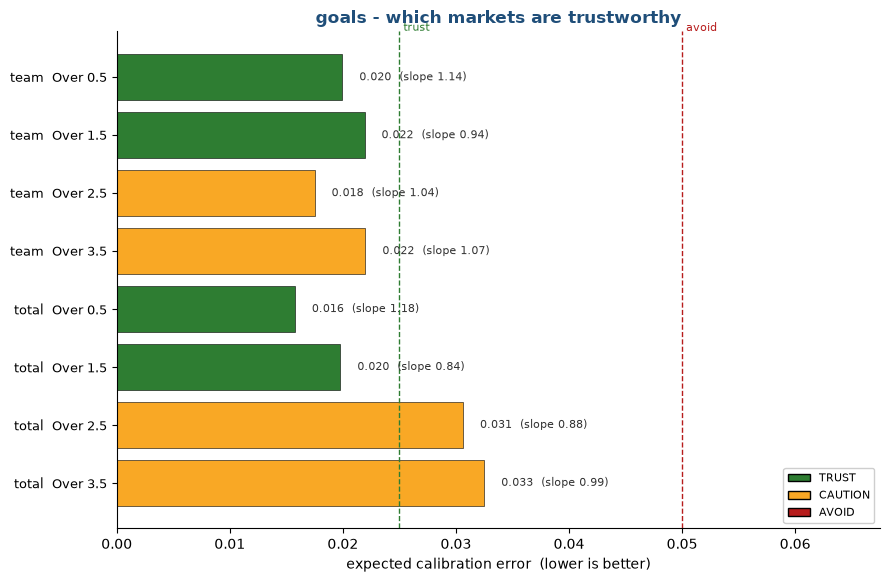

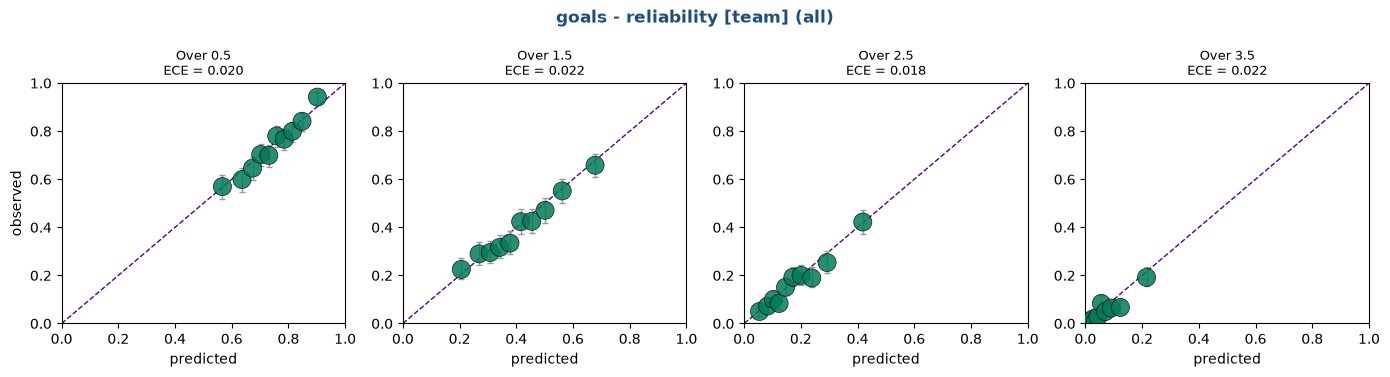

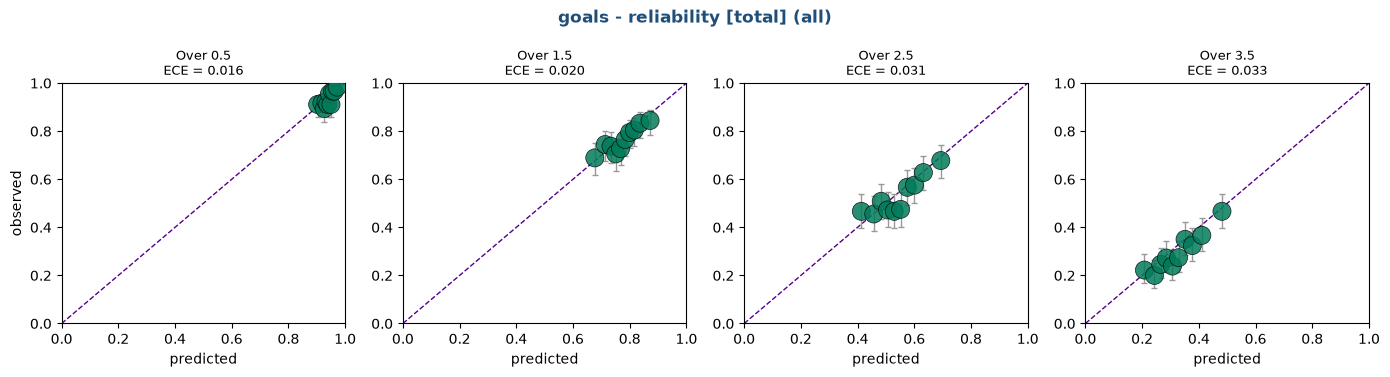

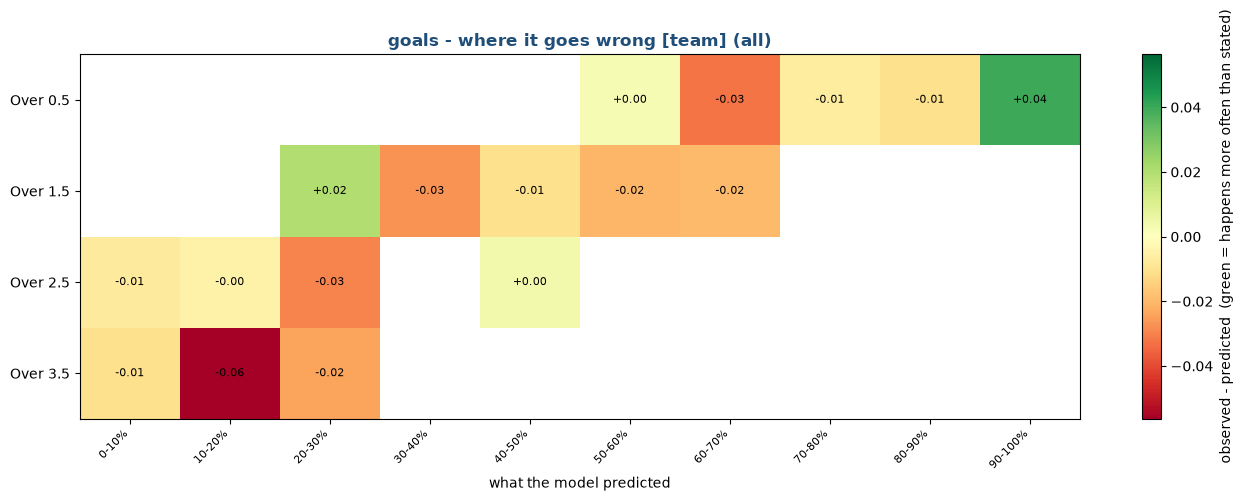

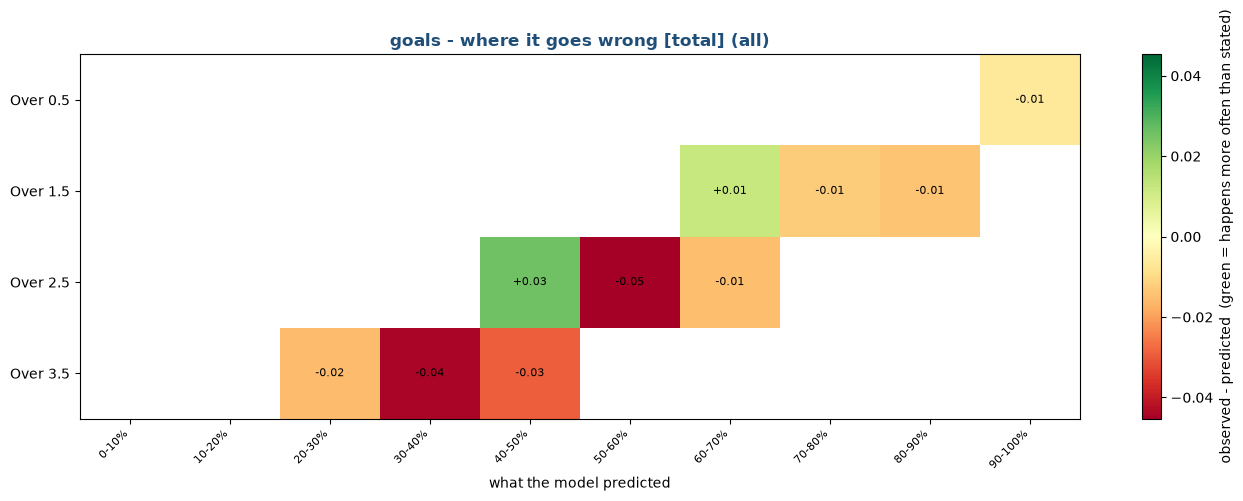

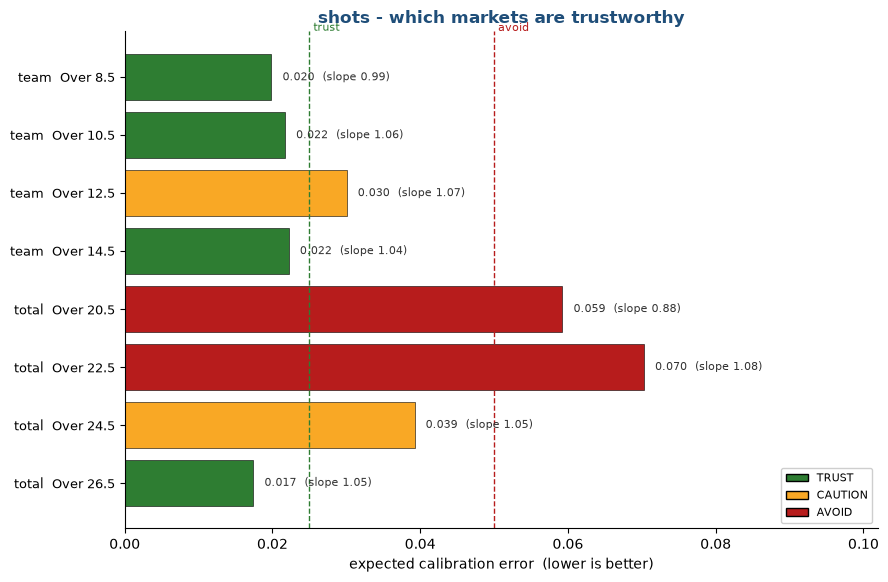

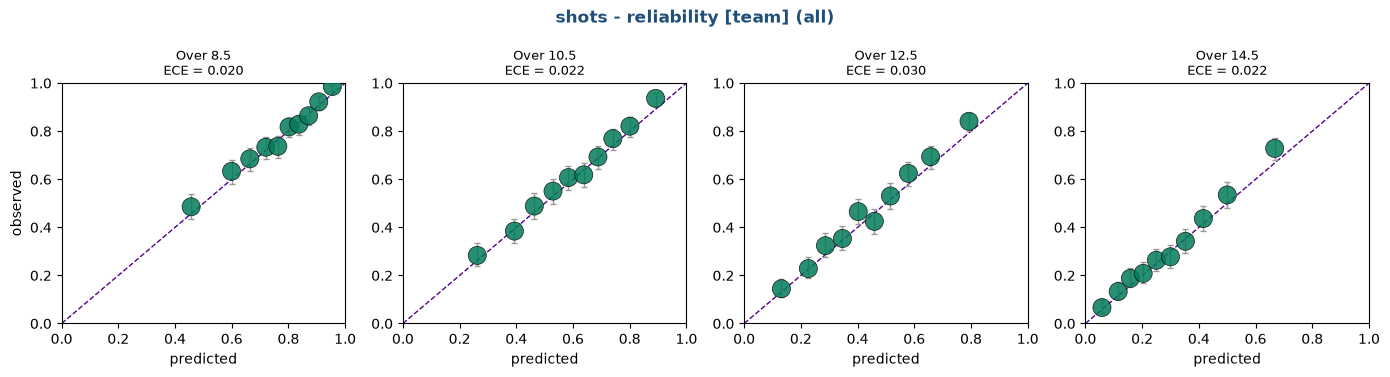

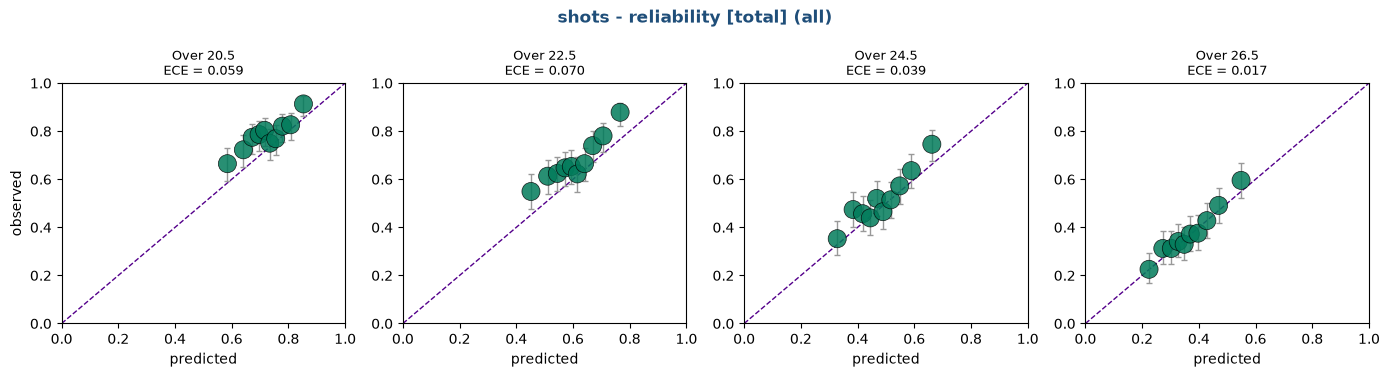

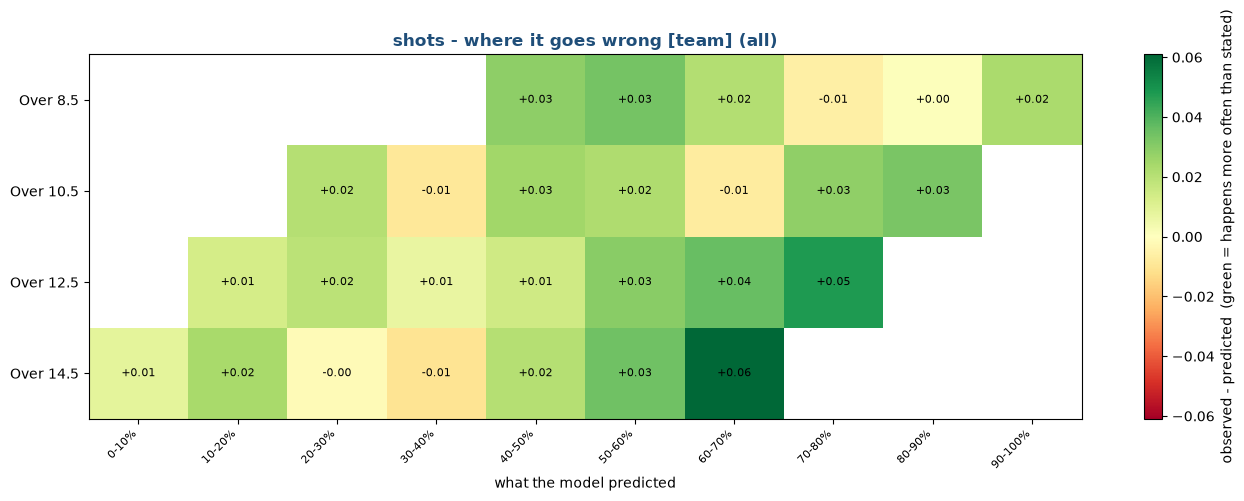

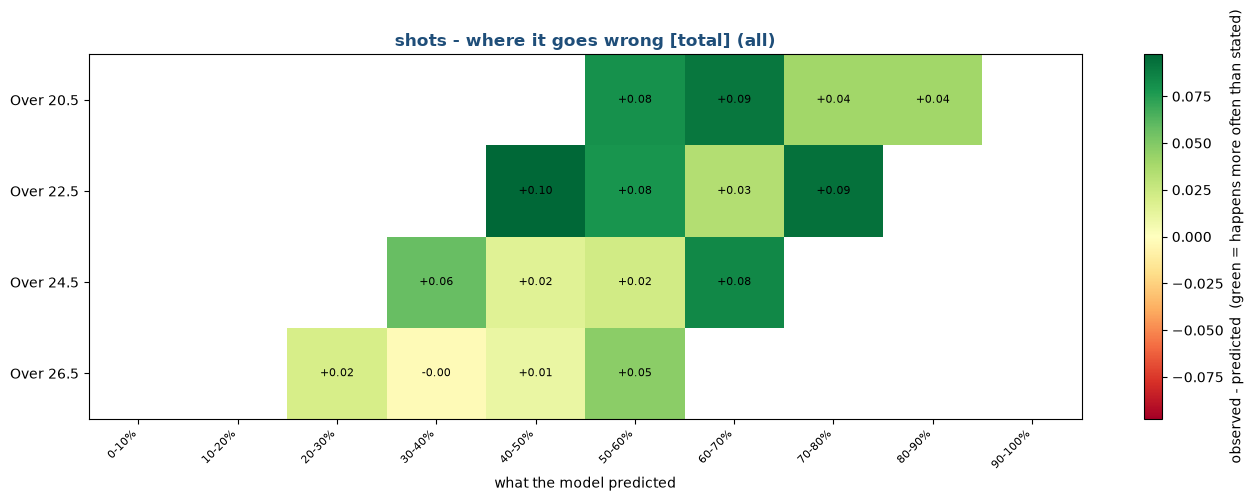

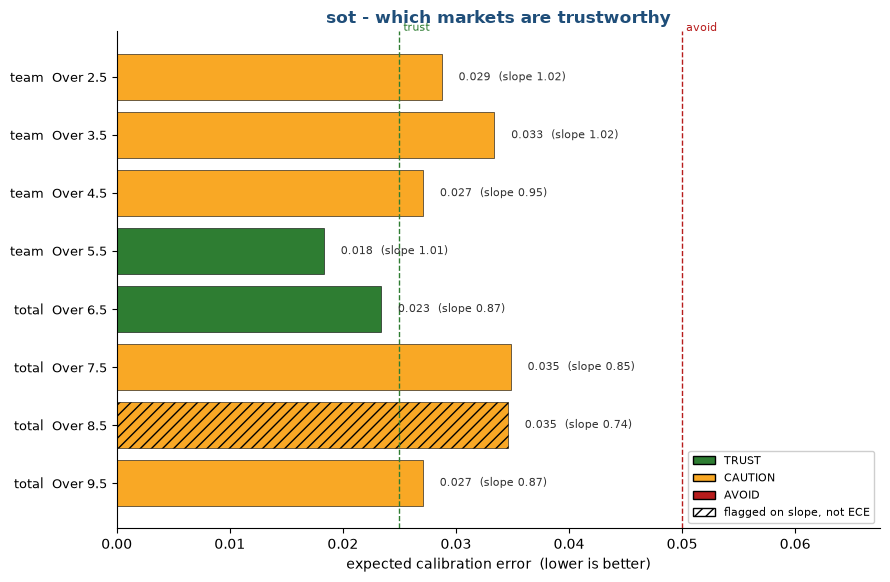

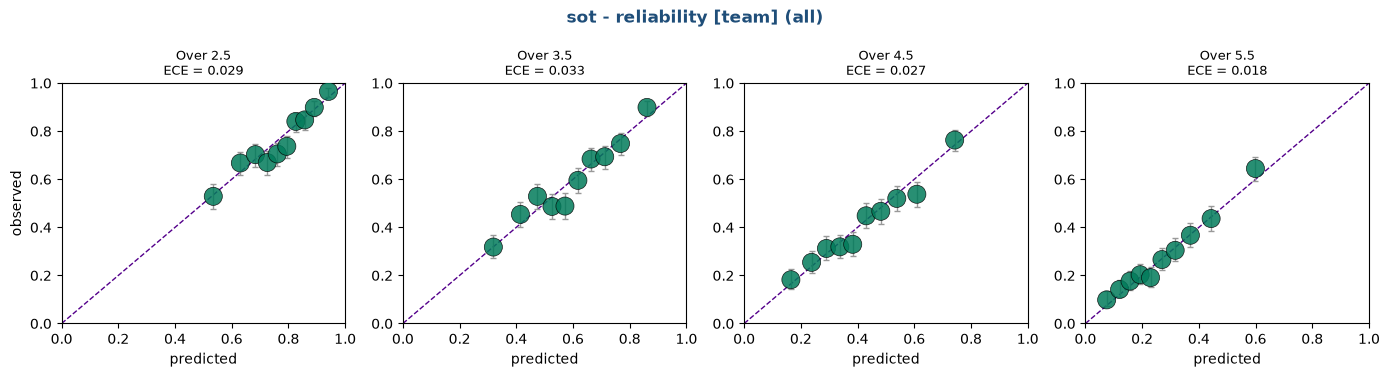

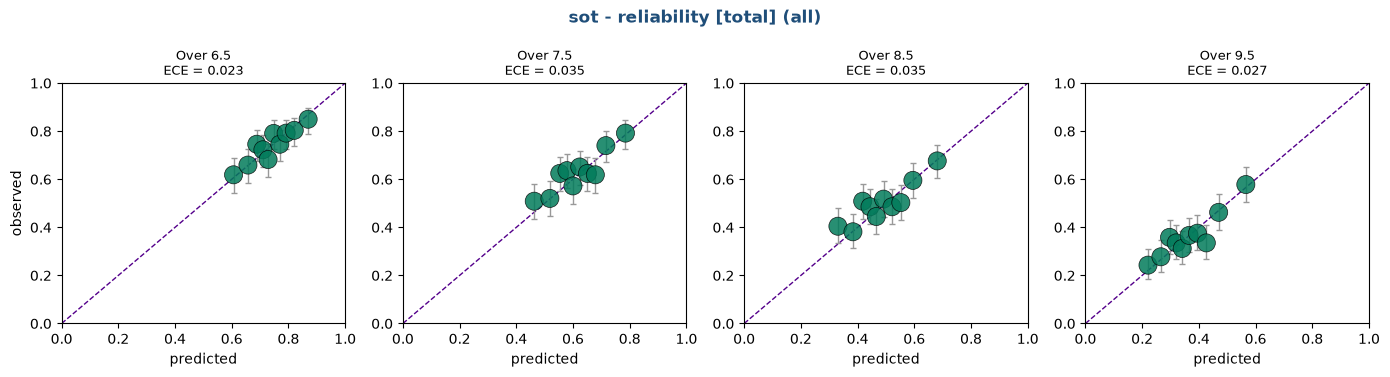

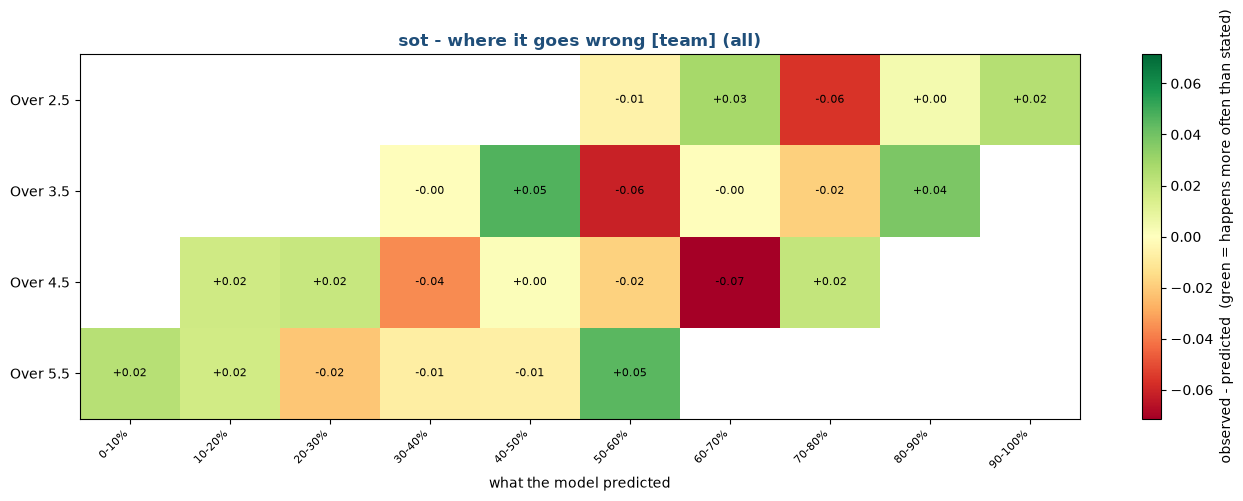

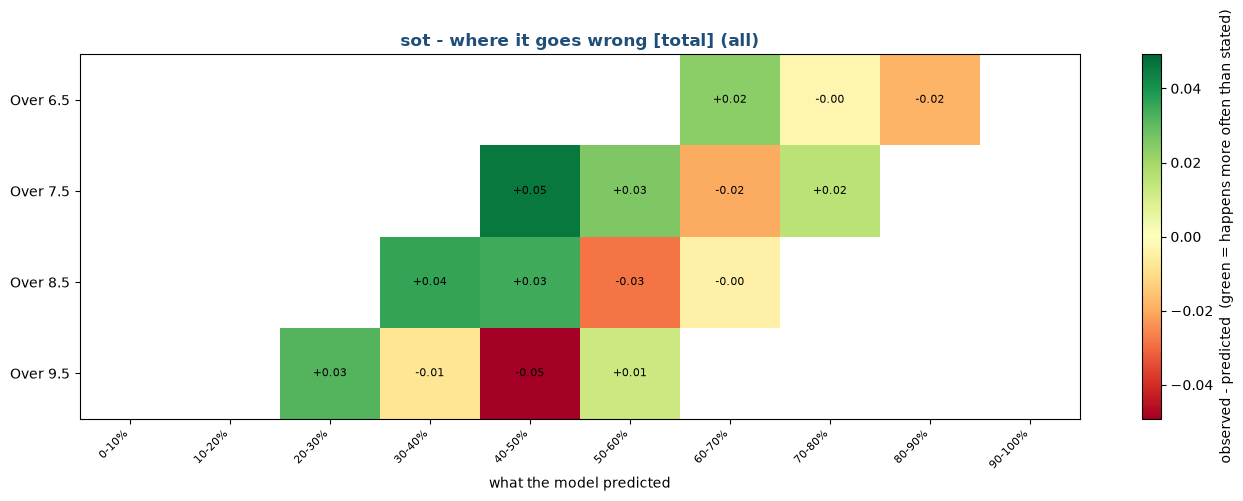

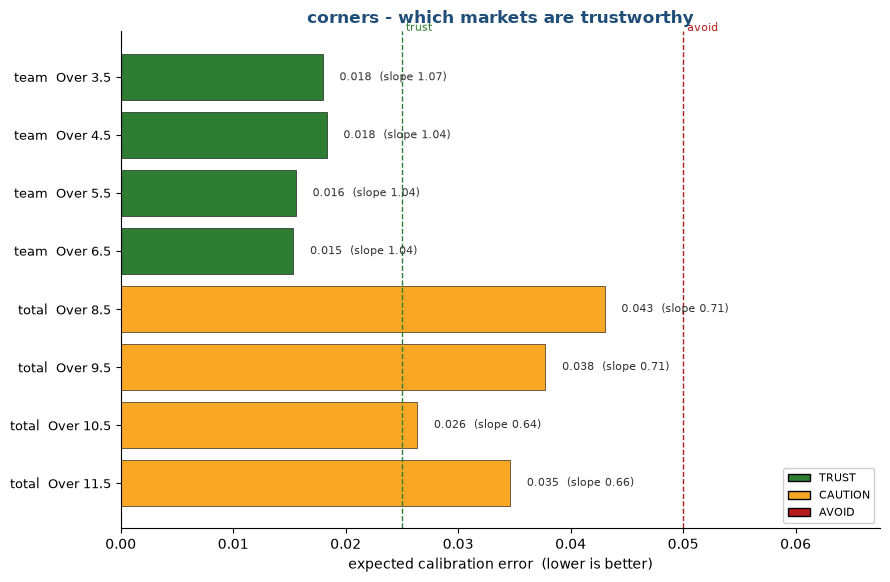

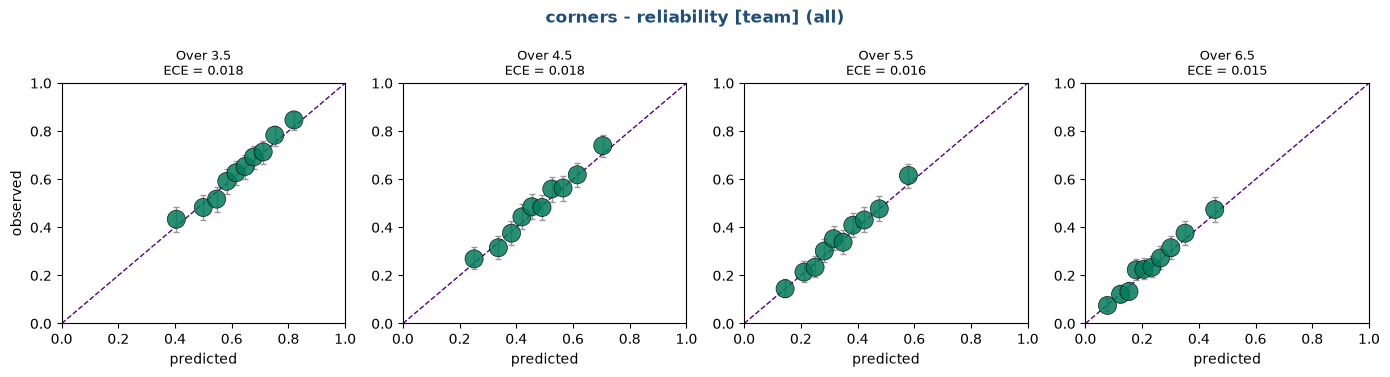

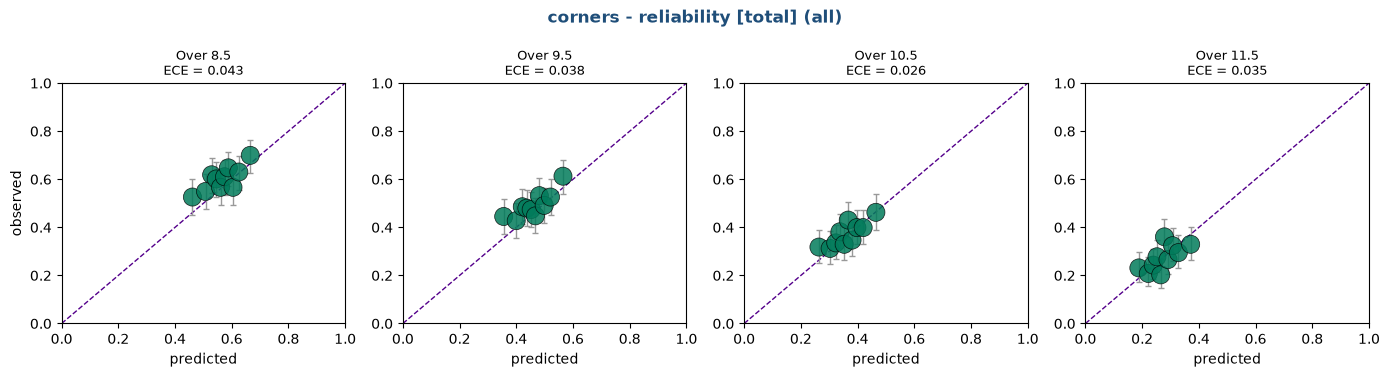

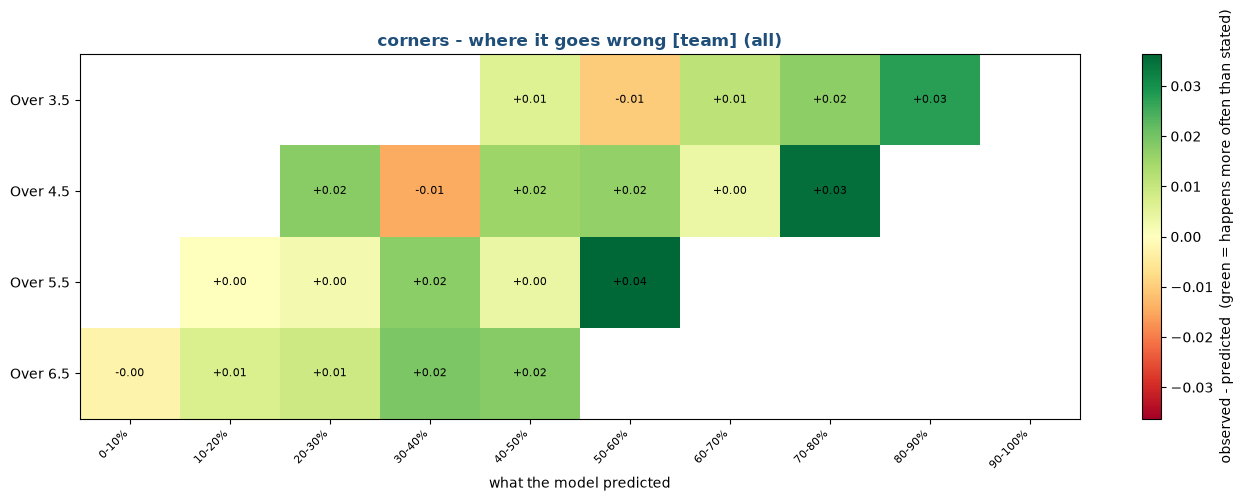

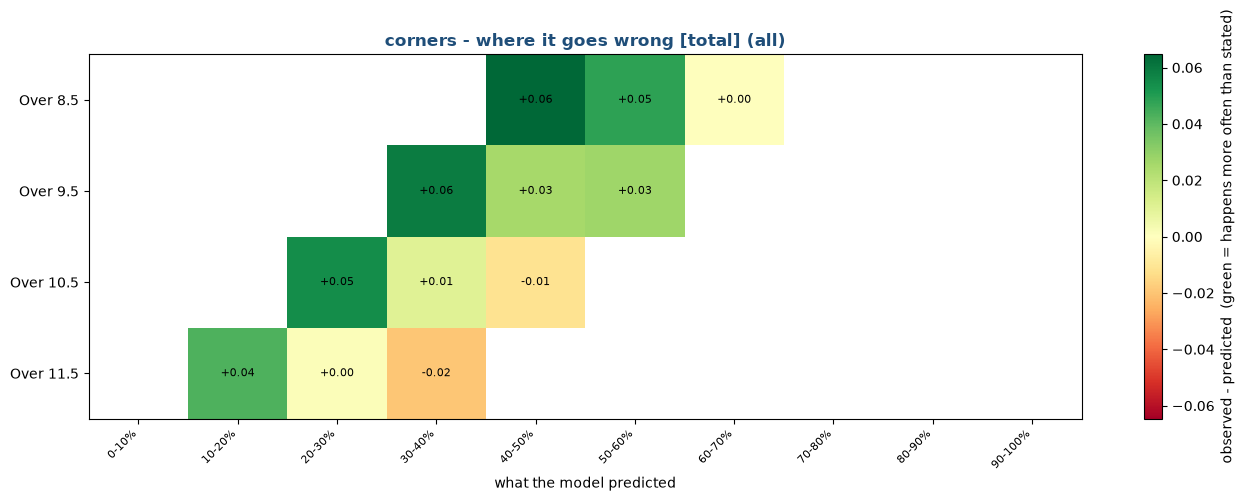

In [8]:
import matplotlib.pyplot as plt

from fpp.report.figures import ece_by_line_figure, gap_heatmap, reliability_figure

for t in fpp.TARGETS:
    for fig in (ece_by_line_figure(cal_summary, t),
                reliability_figure(cal_bins, t, "team"),
                reliability_figure(cal_bins, t, "total"),
                gap_heatmap(cal_bins, t, "team"),
                gap_heatmap(cal_bins, t, "total")):
        if fig is not None:
            plt.show()


### 4c. Leagues and venues

Does any league or venue behave differently from the pooled picture? Venue is
here deliberately -- the fixture workbook's colour baseline pooled home and away
for a long time and it took a visible artefact to catch, so this axis is now
measured rather than assumed.

In [9]:
seg = fpp.calibration.line_verdicts(cal_summary, cal_bins, segment=None)
seg = seg[seg["segment"] != "all"]

pivot = (seg.pivot_table(index=["target", "metric"], columns="segment",
                         values="ece", aggfunc="mean").round(3))
display(pivot)

worst = seg[seg["verdict"] == "AVOID"]
if worst.empty:
    print("No league or venue is flagged AVOID beyond what the pooled table already shows.")
else:
    display(worst[["target", "metric", "segment", "market", "ece", "slope", "verdict"]]
            .sort_values("ece", ascending=False).head(15).round(3))


segment         league:Bund  league:Liga  league:Ligue  league:Prem  \
target  metric                                                        
corners team          0.037        0.038         0.053        0.047   
        total         0.080        0.067         0.059        0.078   
goals   team          0.047        0.039         0.050        0.030   
        total         0.037        0.043         0.056        0.049   
shots   team          0.054        0.037         0.034        0.045   
        total         0.066        0.047         0.066        0.066   
sot     team          0.043        0.045         0.052        0.042   
        total         0.037        0.046         0.041        0.062   

segment         league:Serie  venue:away  venue:home  
target  metric                                        
corners team           0.051       0.026       0.034  
        total          0.063         NaN         NaN  
goals   team           0.033       0.030       0.023  
        total          0.057         NaN         NaN  
shots   team           0.026       0.026       0.040  
        total          0.059         NaN         NaN  
sot     team           0.040       0.033       0.026  
        total          0.041         NaN         NaN

,target,metric,segment,market,ece,slope,verdict
154,shots,total,league:Prem,Over 22.5,0.094,0.498,AVOID
153,shots,total,league:Ligue,Over 22.5,0.093,1.410,AVOID
42,corners,total,league:Prem,Over 9.5,0.091,0.480,AVOID
39,corners,total,league:Bund,Over 9.5,0.091,-0.314,AVOID
33,corners,total,league:Bund,Over 8.5,0.091,-0.257,AVOID
147,shots,total,league:Ligue,Over 20.5,0.090,1.179,AVOID
210,sot,total,league:Prem,Over 7.5,0.084,-0.031,AVOID
36,corners,total,league:Prem,Over 8.5,0.081,0.596,AVOID
105,goals,total,league:Serie,Over 2.5,0.079,-0.092,AVOID
48,corners,total,league:Prem,Over 10.5,0.078,0.211,AVOID


## 5. Worked example

In [10]:
import random
rng = random.Random(2026)
t = "goals"
row = paired_model[t].iloc[rng.randrange(len(paired_model[t]))]
mk = fpp.report.goal_markets(row["mu_home"], row["mu_away"])

print(f"{row['home_team']} vs {row['away_team']}  ({row['league_key']}, {pd.Timestamp(row['date']).date()})")
print(f"  expected goals : {row['mu_home']:.2f} - {row['mu_away']:.2f}")
print(f"  actual         : {int(row['actual_home'])} - {int(row['actual_away'])}")
print(f"  1X2            : {mk['p_home']:.3f} / {mk['p_draw']:.3f} / {mk['p_away']:.3f}")
print(f"  BTTS yes       : {mk['p_btts_yes']:.3f}   (fair odds {1 / mk['p_btts_yes']:.2f})")
print(f"  most likely    : {mk['most_likely'][0]}-{mk['most_likely'][1]} at {mk['most_likely_p']:.3f}")

Juventus vs Atalanta  (Serie, 2025-09-27)
  expected goals : 1.30 - 1.42
  actual         : 1 - 1
  1X2            : 0.345 / 0.257 / 0.398
  BTTS yes       : 0.552   (fair odds 1.81)
  most likely    : 1-1 at 0.122


## 6. Save

In [11]:
out = fpp.paths.OUTPUTS / "Evaluation"
out.mkdir(parents=True, exist_ok=True)

# Every exported frame carries a `metric` column, so a CSV read months from now
# still says which question its numbers answer.
summary.to_csv(out / "test_metrics.csv", index=False)
sig.to_csv(out / "test_significance.csv", index=False)
for t in fpp.TARGETS:
    pd.concat([
        fpp.evaluate.by_league_team(paired_model[t], paired_base[t], t, dispersions[t]),
        fpp.evaluate.by_league_total(paired_model[t], paired_base[t], t, dispersions[t]),
    ], ignore_index=True).to_csv(out / f"test_by_league_{t}.csv", index=False)

# Calibration: the verdict table first, then the working, then the figures, then
# a workbook that needs neither a kernel nor this notebook to be readable.
verdicts.to_csv(out / "calibration_verdicts.csv", index=False)
cal_summary.to_csv(out / "calibration_summary.csv", index=False)
cal_bins.to_csv(out / "calibration_bins.csv", index=False)
figures = fpp.report.figures.save_calibration_figures(cal_summary, cal_bins, out / "Figures")
fpp.report.write_calibration_workbook(cal_summary, cal_bins, figures)

print("saved ->", out)
print(f"scoring mode in force: {fpp.config.SCORING_MODE!r} "
      f"(fingerprint {fpp.spec.scoring_hash()}); artifact version {ctx.version}")


Wrote calibration workbook -> /Users/patrickknott/Desktop/Football_Prediction_Project V2/Outputs/Evaluation/calibration.xlsx
saved -> /Users/patrickknott/Desktop/Football_Prediction_Project V2/Outputs/Evaluation
scoring mode in force: 'team' (fingerprint 5342c5fa); artifact version v2026-08-25
